Colab is making it easier than ever to integrate powerful Generative AI capabilities into your projects. We are launching public preview for a simple and intuitive Python library (google.colab.ai) to access state-of-the-art language models directly within Colab environments. All users have free access to most popular LLMs, while paid users have access to a wider selection of models. This means users can spend less time on configuration and set up and more time bringing their ideas to life. With just a few lines of code, you can now perform a variety of tasks:
- Generate text
- Translate languages
- Write creative content
- Categorize text

Happy Coding!


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb)

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [2]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
from collections import Counter

# Load Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [5]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))

In [6]:
def knn_predict(X_train, y_train, X_test, k):
    predictions = []

    for test in X_test:
        distances = [euclidean_distance(test, x) for x in X_train]
        k_idx = np.argsort(distances)[:k]
        k_labels = [y_train[i] for i in k_idx]

        predictions.append(Counter(k_labels).most_common(1)[0][0])

    return np.array(predictions)

In [7]:
def weighted_knn_predict(X_train, y_train, X_test, k):
    predictions = []

    for test in X_test:
        distances = np.array([euclidean_distance(test, x) for x in X_train])
        k_idx = np.argsort(distances)[:k]

        weights = 1 / (distances[k_idx] + 1e-5)

        class_votes = {}
        for i, idx in enumerate(k_idx):
            label = y_train[idx]
            class_votes[label] = class_votes.get(label, 0) + weights[i]

        predictions.append(max(class_votes, key=class_votes.get))

    return np.array(predictions)

In [8]:
def locally_weighted_predict(X_train, y_train, X_test, k, sigma=1.0):
    predictions = []

    for test in X_test:
        distances = np.array([euclidean_distance(test, x) for x in X_train])
        k_idx = np.argsort(distances)[:k]

        weights = np.exp(-(distances[k_idx]**2) / (2 * sigma**2))

        class_votes = {}
        for i, idx in enumerate(k_idx):
            label = y_train[idx]
            class_votes[label] = class_votes.get(label, 0) + weights[i]

        predictions.append(max(class_votes, key=class_votes.get))

    return np.array(predictions)

In [9]:
def evaluate(y_test, y_pred):
    y_test_bin = label_binarize(y_test, classes=[0,1,2])
    y_pred_bin = label_binarize(y_pred, classes=[0,1,2])

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='macro'),
        "Recall": recall_score(y_test, y_pred, average='macro'),
        "F1 Score": f1_score(y_test, y_pred, average='macro'),
        "Confusion Matrix": confusion_matrix(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test_bin, y_pred_bin, multi_class='ovr')
    }

In [10]:
k_values = [1, 3, 5, 7, 9]

results = []

for k in k_values:
    print(f"\n===== k = {k} =====")

    y_pred_knn = knn_predict(X_train, y_train, X_test, k)
    y_pred_wknn = weighted_knn_predict(X_train, y_train, X_test, k)
    y_pred_lwa = locally_weighted_predict(X_train, y_train, X_test, k)

    res_knn = evaluate(y_test, y_pred_knn)
    res_wknn = evaluate(y_test, y_pred_wknn)
    res_lwa = evaluate(y_test, y_pred_lwa)

    print("\nStandard k-NN:", res_knn)
    print("\nWeighted k-NN:", res_wknn)
    print("\nLocally Weighted:", res_lwa)

    results.append([k, res_knn["Accuracy"], res_wknn["Accuracy"], res_lwa["Accuracy"]])


===== k = 1 =====

Standard k-NN: {'Accuracy': 0.9777777777777777, 'Precision': 0.9761904761904763, 'Recall': 0.9743589743589745, 'F1 Score': 0.974320987654321, 'Confusion Matrix': array([[19,  0,  0],
       [ 0, 12,  1],
       [ 0,  0, 13]]), 'ROC-AUC': np.float64(0.9819711538461539)}

Weighted k-NN: {'Accuracy': 0.9777777777777777, 'Precision': 0.9761904761904763, 'Recall': 0.9743589743589745, 'F1 Score': 0.974320987654321, 'Confusion Matrix': array([[19,  0,  0],
       [ 0, 12,  1],
       [ 0,  0, 13]]), 'ROC-AUC': np.float64(0.9819711538461539)}

Locally Weighted: {'Accuracy': 0.9777777777777777, 'Precision': 0.9761904761904763, 'Recall': 0.9743589743589745, 'F1 Score': 0.974320987654321, 'Confusion Matrix': array([[19,  0,  0],
       [ 0, 12,  1],
       [ 0,  0, 13]]), 'ROC-AUC': np.float64(0.9819711538461539)}

===== k = 3 =====

Standard k-NN: {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0, 'Confusion Matrix': array([[19,  0,  0],
       [ 0, 13,  0],


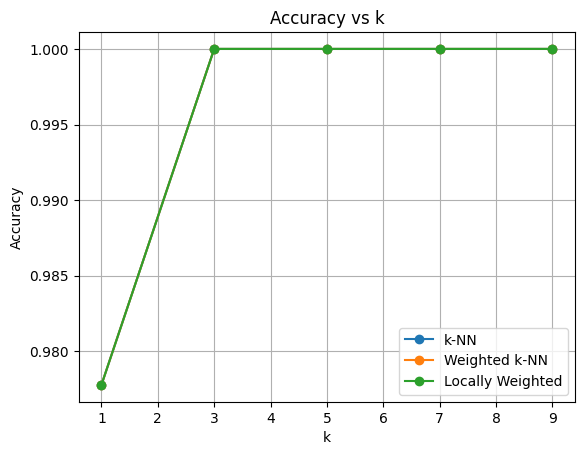

In [11]:
results = np.array(results)

plt.plot(results[:,0], results[:,1], marker='o', label="k-NN")
plt.plot(results[:,0], results[:,2], marker='o', label="Weighted k-NN")
plt.plot(results[:,0], results[:,3], marker='o', label="Locally Weighted")

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k")
plt.legend()
plt.grid()
plt.show()